In [255]:
from langgraph.graph import StateGraph

In [256]:
import importlib.metadata

print(importlib.metadata.version("langgraph"))

1.2.0


In [257]:
from langgraph.graph import StateGraph
from langchain_groq import ChatGroq
import os
from dotenv import load_dotenv

load_dotenv()

GROQ_API_KEY=os.getenv("GROQ_API_KEY")

In [258]:
llm=ChatGroq(
    model="llama-3.1-8b-instant",
)

In [259]:
llm.invoke("What is the machine learning").content


'**Machine Learning (ML)** is a subset of Artificial Intelligence (AI) that involves the development of algorithms and statistical models that enable computers to perform a specific task without being explicitly programmed. The primary goal of ML is to enable machines to learn from data and improve their performance on a particular task over time.\n\n**Key Characteristics of Machine Learning:**\n\n1. **Data-Driven**: ML algorithms rely on large amounts of data to learn and improve their performance.\n2. **Autonomous**: ML systems can operate independently, making decisions and taking actions without human intervention.\n3. **Adaptive**: ML algorithms can adapt to new data, changing conditions, and evolving requirements.\n4. **Scalable**: ML systems can be trained on large datasets and can handle complex, high-dimensional data.\n\n**Types of Machine Learning:**\n\n1. **Supervised Learning**: The algorithm is trained on labeled data, where the correct output is already known. Examples in

In [260]:
def function1(input):
    llm=ChatGroq(model="llama-3.1-8b-instant")
    response = llm.invoke("Hi How are you").content
    return response


In [261]:
def function2(input):
    upper_string = input.upper()
    return upper_string

In [262]:
function2("Hello")

'HELLO'

In [263]:
workflow = StateGraph(input)

c:\Users\TOMICHAN\anaconda3\envs\training\Lib\site-packages\langgraph\graph\state.py:116: UserWarning: Invalid state_schema: <bound method Kernel.raw_input of <ipykernel.ipkernel.IPythonKernel object at 0x000002891E34A120>>. Expected a type or Annotated[type, reducer]. Please provide a valid schema to ensure correct updates.
 See: https://langchain-ai.github.io/langgraph/reference/graphs/#stategraph
  warnings.warn(


In [264]:
workflow.add_node("llm",function1)
workflow.add_node("function2",function2)

In [265]:
from langgraph.graph import START, END

In [266]:
workflow.add_edge(START, "llm")
workflow.add_edge("llm", "function2")
workflow.add_edge("function2", END)

In [267]:
workflow.set_entry_point("llm")

In [268]:
workflow.set_finish_point("function2")

In [269]:
app=workflow.compile()

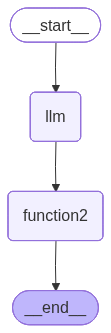

In [270]:
from IPython.display import display,Image

try :
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)


In [272]:
def function1(state):
    response = llm.invoke("Hi How are you").content

    return {
        "messages": [
            {
                "role": "assistant",
                "content": response
            }
        ]
    }

In [273]:
function1("Hello")

{'messages': [{'role': 'assistant',
   'content': "I'm doing well, thank you for asking. I'm a large language model, so I don't have emotions or feelings like humans do, but I'm here and ready to help with any questions or topics you'd like to discuss. How can I assist you today?"}]}